# 01 Exploration

Load all local CRMLS sold CSV files from `data/raw/` and run initial exploration for the California close price prediction project.

In [37]:
# Import Libraries
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

# 1. Dataset Overview

### Load Data

In [38]:
# Load every local CRMLS sold CSV file.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

csv_files = sorted(RAW_DATA_DIR.glob("CRMLSSold*.csv"))

print(f"Found {len(csv_files)} CRMLSSold CSV files")

for path in csv_files:
    print(path.name)

Found 14 CRMLSSold CSV files
CRMLSSold202504.csv
CRMLSSold202505.csv
CRMLSSold202506.csv
CRMLSSold202507.csv
CRMLSSold202508.csv
CRMLSSold202509.csv
CRMLSSold202510.csv
CRMLSSold202511.csv
CRMLSSold202512.csv
CRMLSSold202601.csv
CRMLSSold202602.csv
CRMLSSold202603.csv
CRMLSSold202604.csv
CRMLSSold202605.csv


In [39]:
# Load a CRMLS CSV and add source_file so each row can be traced back to its original file.
def load_crmls_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    df["source_file"] = path.name
    return df


# Store each monthly file separately first, then concatenate into one analysis DataFrame.
dataframes = []
file_summary = []

for path in csv_files:
    df = load_crmls_file(path)
    dataframes.append(df)

    # Keep a compact file-level summary to check row counts and schema consistency across files.
    file_summary.append(
        {
            "source_file": path.name,
            "rows": len(df),
            "columns": df.shape[1],
        }
    )

# Combine all monthly files into one raw dataset.
raw_df = pd.concat(dataframes, ignore_index=True)
file_summary_df = pd.DataFrame(file_summary)

print(f"Combined shape: {raw_df.shape}")
file_summary_df

Combined shape: (305085, 79)


,source_file,rows,columns
0,CRMLSSold202504.csv,23262,79
1,CRMLSSold202505.csv,23154,79
2,CRMLSSold202506.csv,22883,79
3,CRMLSSold202507.csv,23646,79
4,CRMLSSold202508.csv,22972,79
5,CRMLSSold202509.csv,22443,79
6,CRMLSSold202510.csv,23233,79
7,CRMLSSold202511.csv,19088,79
8,CRMLSSold202512.csv,20538,79
9,CRMLSSold202601.csv,16487,79


In [40]:
# Inspect column names, inferred dtypes, non-null counts, and approximate memory usage.
raw_df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 305085 entries, 0 to 305084
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 298950 non-null  str    
 1   ListAgentAOR                  304961 non-null  str    
 2   Flooring                      179226 non-null  str    
 3   ViewYN                        274399 non-null  object 
 4   WaterfrontYN                  181 non-null     object 
 5   BasementYN                    5007 non-null    object 
 6   PoolPrivateYN                 272030 non-null  object 
 7   OriginalListPrice             304171 non-null  float64
 8   ListingKey                    305085 non-null  int64  
 9   ListAgentEmail                304191 non-null  str    
 10  CloseDate                     305085 non-null  str    
 11  ClosePrice                    305081 non-null  float64
 12  ListAgentFirstName            303689 non-null  str    


### Filter to Project Scope

The task prompt says to model only records where `PropertyType == "Residential"` and `PropertySubType == "SingleFamilyResidence"`.

In [41]:
# Check the main filtering fields.
for col in ["PropertyType", "PropertySubType", "MlsStatus"]:
    if col in raw_df.columns:
        display(raw_df[col].value_counts(dropna=False).head(20).to_frame("count"))

,count
PropertyType,
Residential,204401
ResidentialLease,71492
Land,9539
ResidentialIncome,8259
ManufacturedInPark,7864
CommercialSale,1848
CommercialLease,1508
BusinessOpportunity,174


,count
PropertySubType,
SingleFamilyResidence,187043
Condominium,52639
NaN,22151
Townhouse,17362
Apartment,7770
Duplex,5922
ManufacturedOnLand,3129
Triplex,1947
Quadruplex,1883


,count
MlsStatus,
Closed,305085


In [42]:
# Filter the dataset.
df = raw_df[
    (raw_df["PropertyType"] == "Residential") &
    (raw_df["PropertySubType"].astype(str).str.replace(" ", "", regex=False) == "SingleFamilyResidence")
].copy()


print(f"Original rows: {raw_df.shape[0]:,}")
print(f"Filtered rows: {df.shape[0]:,}")
print(f"Remaining ratio: {df.shape[0] / raw_df.shape[0]:.2%}")

Original rows: 305,085
Filtered rows: 153,877
Remaining ratio: 50.44%


# 2. Check Target variable: ClosePrice

In [43]:
# Convert the target variable to numeric.
df["ClosePrice"] = pd.to_numeric(df["ClosePrice"], errors="coerce")

In [44]:
# Check whether the target has missing, invalid, or non-positive values.
print(f"Number of missing values in ClosePrice: {df['ClosePrice'].isna().sum()}")
print(f"Number of non-positive values in ClosePrice: {(df['ClosePrice'] <= 0).sum()}")
print(f"Description of ClosePrice:\n{df['ClosePrice'].describe()}")

Number of missing values in ClosePrice: 0
Number of non-positive values in ClosePrice: 1
Description of ClosePrice:
count    1.538770e+05
mean     1.345657e+06
std      8.159944e+06
min      0.000000e+00
25%      6.250000e+05
50%      8.930000e+05
75%      1.425000e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64


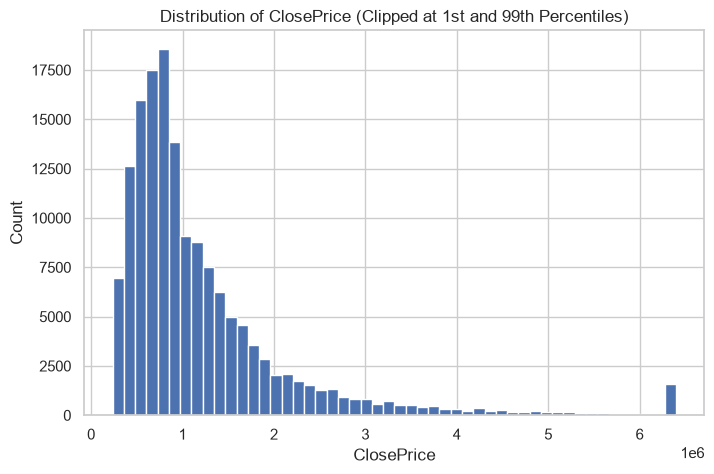

In [45]:
# Use percentile clipping only for plotting the target distribution.
# This keeps extreme luxury sales from compressing the main body of the histogram.
lower = df["ClosePrice"].quantile(0.01)
upper = df["ClosePrice"].quantile(0.99)

plt.figure(figsize=(8, 5))
df["ClosePrice"].dropna().clip(lower, upper).hist(bins=50)
plt.xlabel("ClosePrice")
plt.ylabel("Count")
plt.title("Distribution of ClosePrice (Clipped at 1st and 99th Percentiles)")
plt.show()

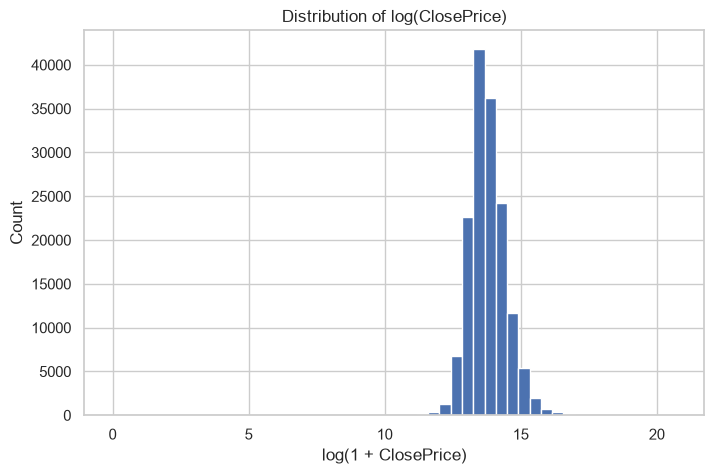

In [46]:
# Plot log-transformed ClosePrice to see whether the target becomes more symmetric.
# log1p is commonly used for right-skewed price targets.
plt.figure(figsize=(8, 5))
np.log1p(df["ClosePrice"].dropna()).hist(bins=50)
plt.xlabel("log(1 + ClosePrice)")
plt.ylabel("Count")
plt.title("Distribution of log(ClosePrice)")
plt.show()

# 3. Data Quality Checks

### Duplicate ListingKey

In [47]:
# Quick duplicate ListingKey check.
# Goal: understand whether duplicate rows are mostly repeated listings across monthly files.
duplicated_listing_keys = (
    df.dropna(subset=["ListingKey"])
    .groupby("ListingKey")
    .agg(
        n_rows=("ListingKey", "size"),
        n_files=("source_file", "nunique"),
        files=("source_file", lambda x: ", ".join(sorted(x.unique()))),
    )
    .query("n_rows > 1")
    .sort_values(["n_files", "n_rows"], ascending=False)
)

duplicated_rows = df[df["ListingKey"].isin(duplicated_listing_keys.index)].copy()
duplicated_rows["source_month"] = duplicated_rows["source_file"].str.extract(r"(\d{6})")[0]
duplicated_rows["CloseDate_dt"] = pd.to_datetime(duplicated_rows["CloseDate"], errors="coerce")

print(f"Duplicated ListingKeys: {len(duplicated_listing_keys):,}")
print(f"Extra rows from duplicates: {(duplicated_listing_keys['n_rows'] - 1).sum():,}")
print(f"Across-file duplicate keys: {(duplicated_listing_keys['n_files'] > 1).sum():,}")
print(f"Within-file duplicate keys: {(duplicated_listing_keys['n_files'] == 1).sum():,}")

display(duplicated_listing_keys.head(10))

Duplicated ListingKeys: 110
Extra rows from duplicates: 112
Across-file duplicate keys: 102
Within-file duplicate keys: 8


,n_rows,n_files,files
ListingKey,,,
1101502229,3,3,"CRMLSSold202505.csv, CRMLSSold202506.csv, CRML..."
1137564166,3,3,"CRMLSSold202511.csv, CRMLSSold202512.csv, CRML..."
1075843364,2,2,"CRMLSSold202506.csv, CRMLSSold202508.csv"
1076103978,2,2,"CRMLSSold202505.csv, CRMLSSold202506.csv"
1090949274,2,2,"CRMLSSold202504.csv, CRMLSSold202505.csv"
1095200789,2,2,"CRMLSSold202504.csv, CRMLSSold202505.csv"
1100602206,2,2,"CRMLSSold202505.csv, CRMLSSold202506.csv"
1100628753,2,2,"CRMLSSold202505.csv, CRMLSSold202506.csv"
1100754427,2,2,"CRMLSSold202506.csv, CRMLSSold202507.csv"


In [48]:
# Quick check for whether keeping the latest duplicate row is reasonable.
# We compare transaction fields and stable property fields separately.
fields_to_check = [
    "CloseDate",
    "ClosePrice",
    "ListPrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "City",
    "PostalCode",
]
fields_to_check = [col for col in fields_to_check if col in duplicated_rows.columns]

field_variation = (
    duplicated_rows.groupby("ListingKey")[fields_to_check]
    .nunique(dropna=False)
    .gt(1)
    .sum()
    .sort_values(ascending=False)
    .to_frame("n_duplicate_keys_with_different_values")
)

display(field_variation)

,n_duplicate_keys_with_different_values
CloseDate,102
ClosePrice,26
ListPrice,3
LivingArea,0
BedroomsTotal,0
BathroomsTotalInteger,0
LotSizeSquareFeet,0
YearBuilt,0
Latitude,0
Longitude,0


### Coordinates

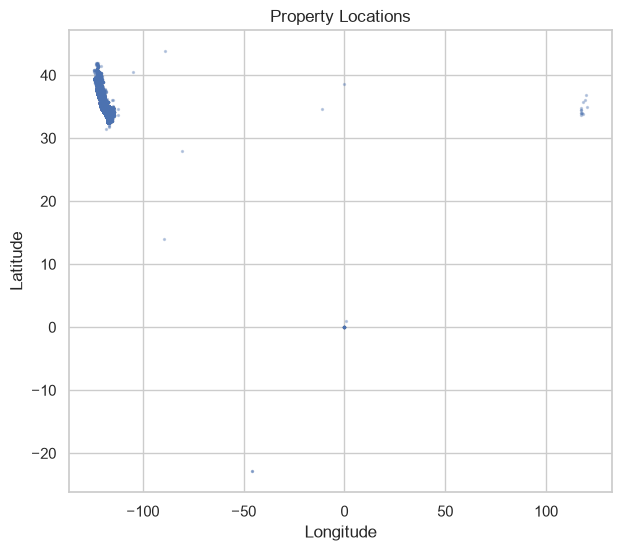

In [49]:
# Quick coordinate scatter plot to confirm the records are located in California.
plt.figure(figsize=(7, 6))
plt.scatter(df["Longitude"], df["Latitude"], s=2, alpha=0.3)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Property Locations")
plt.show()

In [50]:
display(df[["Latitude", "Longitude"]].describe())

# Flag coordinates outside the expected California range.
# These records may need to be removed or have coordinates set to missing before modeling.
ca_lat_min, ca_lat_max = 32.0, 42.5
ca_lon_min, ca_lon_max = -125.0, -114.0

outside_ca = df[
    (df["Latitude"] < ca_lat_min) |
    (df["Latitude"] > ca_lat_max) |
    (df["Longitude"] < ca_lon_min) |
    (df["Longitude"] > ca_lon_max)
]

print(f"Number of properties outside California: {outside_ca.shape[0]}")

,Latitude,Longitude
count,153863.000000,153863.000000
mean,34.730530,-118.597619
std,1.756807,3.155212
min,-22.863239,-124.193201
25%,33.760230,-119.141226
50%,34.082658,-118.029220
75%,34.757904,-117.259077
max,43.784440,120.432670


Number of properties outside California: 46


In [51]:
# Review Coordinate Outliers
# Inspect the location fields for records outside the expected California coordinate range.
# If City/County/ZIP/address are still valid, it is usually better to keep the row
# and only flag or null out the bad coordinate values during preprocessing.
coordinate_review_cols = [
    "ListingKey",
    "CloseDate",
    "City",
    "CountyOrParish",
    "PostalCode",
    "Latitude",
    "Longitude",
    "UnparsedAddress",
    "ClosePrice",
    "source_file",
]

available_coordinate_review_cols = [col for col in coordinate_review_cols if col in outside_ca.columns]

outside_ca_review = (
    outside_ca[available_coordinate_review_cols]
    .sort_values(["CountyOrParish", "City", "PostalCode", "CloseDate"], na_position="last")
    .reset_index(drop=True)
)


if "CountyOrParish" in outside_ca_review.columns:
    print("\nCounty counts:")
    display(outside_ca_review["CountyOrParish"].value_counts(dropna=False).to_frame("count"))

if "City" in outside_ca_review.columns:
    print("\nCity counts:")
    display(outside_ca_review["City"].value_counts(dropna=False).to_frame("count"))


County counts:


,count
CountyOrParish,
Monterey,10
Los Angeles,9
Other,4
Riverside,4
San Benito,3
San Bernardino,3
Foreign Country,2
Fresno,2
San Joaquin,2



City counts:


,count
City,
Marina,7
Other,5
Palmdale,3
Hollister,3
Fresno,2
Lancaster,2
Carmel,2
NaN,2
Los Gatos,2


## 4. Missing Values and Candidate Feature Groups

In [52]:
# Calculate missing value rate for every column after filtering to the project scope.
# Keep both a detailed table and a compact grouped summary for presentation.
missing = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
missing.columns = ["column", "missing_rate"]

missing["missing_group"] = pd.cut(
    missing["missing_rate"],
    bins=[-0.01, 0, 0.05, 0.25, 0.50, 0.80, 1.00],
    labels=["0%", "0-5%", "5-25%", "25-50%", "50-80%", "80-100%"],
)

missing_group_summary = (
    missing["missing_group"]
    .value_counts(sort=False)
    .rename_axis("missing_rate_group")
    .reset_index(name="n_columns")
)

# This table is good for slides because it summarizes missingness without listing every column.
display(missing_group_summary)

# Keep the detailed top missing columns for preprocessing decisions.
display(missing.head(30))

,missing_rate_group,n_columns
0,0%,17
1,0-5%,27
2,5-25%,8
3,25-50%,4
4,50-80%,5
5,80-100%,18


,column,missing_rate,missing_group
0,CoveredSpaces,1.000000,80-100%
1,MiddleOrJuniorSchoolDistrict,1.000000,80-100%
2,AboveGradeFinishedArea,1.000000,80-100%
3,FireplacesTotal,1.000000,80-100%
4,TaxYear,1.000000,80-100%
5,ElementarySchoolDistrict,1.000000,80-100%
6,BusinessType,1.000000,80-100%
7,TaxAnnualAmount,1.000000,80-100%
8,WaterfrontYN,0.999467,80-100%
9,BelowGradeFinishedArea,0.992949,80-100%


In [53]:
# Draft feature lists for the next preprocessing/modeling notebook.
drop_cols = [
    # Target
    "ClosePrice",

    # leakage
    "ListPrice",
    "OriginalListPrice",
    "CloseDate",

    # IDs
    "ListingKey",
    "ListingKeyNumeric",
    "ListingId",

    # 100% missing
    "CoveredSpaces",
    "MiddleOrJuniorSchoolDistrict",
    "TaxYear",
    "ElementarySchoolDistrict",
    "BusinessType",
    "TaxAnnualAmount",
    "FireplacesTotal",
    "AboveGradeFinishedArea",

    # Very high missing (> 80%)
    "WaterfrontYN",
    "BelowGradeFinishedArea",
    "BasementYN",
    "BuilderName",
    "LotSizeDimensions",
    "BuildingAreaTotal",
    "CoBuyerAgentFirstName",
    "MiddleOrJuniorSchool",
    "ElementarySchool",
    "HighSchool",

    # Agent / office fields
    "ListAgentEmail",
    "ListAgentFirstName",
    "ListAgentLastName",
    "ListAgentFullName",
    "CoListAgentFirstName",
    "CoListAgentLastName",
    "BuyerAgentFirstName",
    "BuyerAgentLastName",
    "BuyerAgentMlsId",
    "ListOfficeName",
    "BuyerOfficeName",
    "CoListOfficeName",
    "BuyerAgentAOR",
    "ListAgentAOR",
    "BuyerOfficeAOR",

    # Transaction timing / potential leakage for first model
    "PurchaseContractDate",
    "ContractStatusChangeDate",
    "DaysOnMarket",

    # Too sparse or not needed initially
    "SubdivisionName",
    "AssociationFeeFrequency",
    "MainLevelBedrooms",    # 39% missing + 'BedroomsTotal' already provides similar information.
    "StateOrProvince"
]

# Continuous numeric predictors.
# These behave like measured quantities and may need scaling, clipping, or log transforms.
continuous_numeric_cols = [
    "LivingArea",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "AssociationFee"
]

# Count / ordinal numeric predictors.
# These are numeric, but they are discrete counts rather than continuous measurements.
# For linear models, we can compare using them as numeric vs one-hot/ordinal encoded features.
count_numeric_cols = [
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "GarageSpaces",
    "ParkingTotal",
    "Stories"
]

# Combined numeric list used for numeric summaries and correlation checks.
numeric_cols = continuous_numeric_cols + count_numeric_cols

# Boolean-like predictors that may need conversion from strings/YN values before modeling.
boolean_cols = [
    "ViewYN",
    "PoolPrivateYN",
    "AttachedGarageYN",
    "FireplaceYN",
    "NewConstructionYN"
]

# Categorical predictors that may need encoding or rare-category grouping.
categorical_cols = [
    "City",
    "CountyOrParish",
    "PostalCode",
    "MLSAreaMajor",
    "Levels",
    "Flooring",
    "HighSchoolDistrict"
]

### Continuous and Count Numeric Feature Summary


In [54]:
# Convert candidate numeric features to numeric dtype.
# Invalid strings become NaN so summaries and plots do not fail.
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

available_continuous_cols = [col for col in continuous_numeric_cols if col in df.columns]
available_count_cols = [col for col in count_numeric_cols if col in df.columns]
available_numeric_cols = available_continuous_cols + available_count_cols

# Compact numeric summary for preprocessing decisions.
# feature_type separates continuous measurements from discrete count/ordinal variables.
numeric_summary = df[available_numeric_cols].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max",
]).T

numeric_summary["feature_type"] = [
    "continuous" if col in available_continuous_cols else "count/ordinal"
    for col in numeric_summary.index
]
numeric_summary["missing_rate"] = df[available_numeric_cols].isna().mean()
numeric_summary["skew"] = df[available_numeric_cols].skew(numeric_only=True)

# Reorder columns so the most useful EDA fields appear first.
numeric_summary = numeric_summary[
    ["feature_type", "count", "missing_rate", "mean", "median", "std", "min", "max", "skew"]
]

display(numeric_summary)

,feature_type,count,missing_rate,mean,median,std,min,max,skew
LivingArea,continuous,153793.0,0.000546,2047.700772,1819.000000,1.042001e+03,0.000000,5.650000e+04,3.982925
LotSizeSquareFeet,continuous,151222.0,0.017254,347316.727963,7288.000000,1.677799e+07,0.000000,1.938943e+09,76.163545
YearBuilt,continuous,153774.0,0.000669,1975.803783,1976.000000,2.761210e+01,1776.000000,2.026000e+03,-0.167442
Latitude,continuous,153863.0,0.000091,34.730530,34.082658,1.756807e+00,-22.863239,4.378444e+01,-0.362480
Longitude,continuous,153863.0,0.000091,-118.597619,-118.029220,3.155212e+00,-124.193201,1.204327e+02,40.789547
AssociationFee,continuous,109021.0,0.291506,106.116269,0.000000,3.386113e+02,0.000000,2.071200e+04,18.598139
BedroomsTotal,count/ordinal,153877.0,0.000000,3.491373,3.000000,9.689069e-01,0.000000,4.500000e+01,1.224600
BathroomsTotalInteger,count/ordinal,153861.0,0.000104,2.632025,2.000000,1.136319e+00,0.000000,4.500000e+01,2.423846
GarageSpaces,count/ordinal,147780.0,0.039623,2.005951,2.000000,3.349255e+00,0.000000,6.000000e+02,123.764677
ParkingTotal,count/ordinal,153876.0,0.000006,3.110881,2.000000,4.951816e+01,-35.000000,1.572000e+04,265.146026


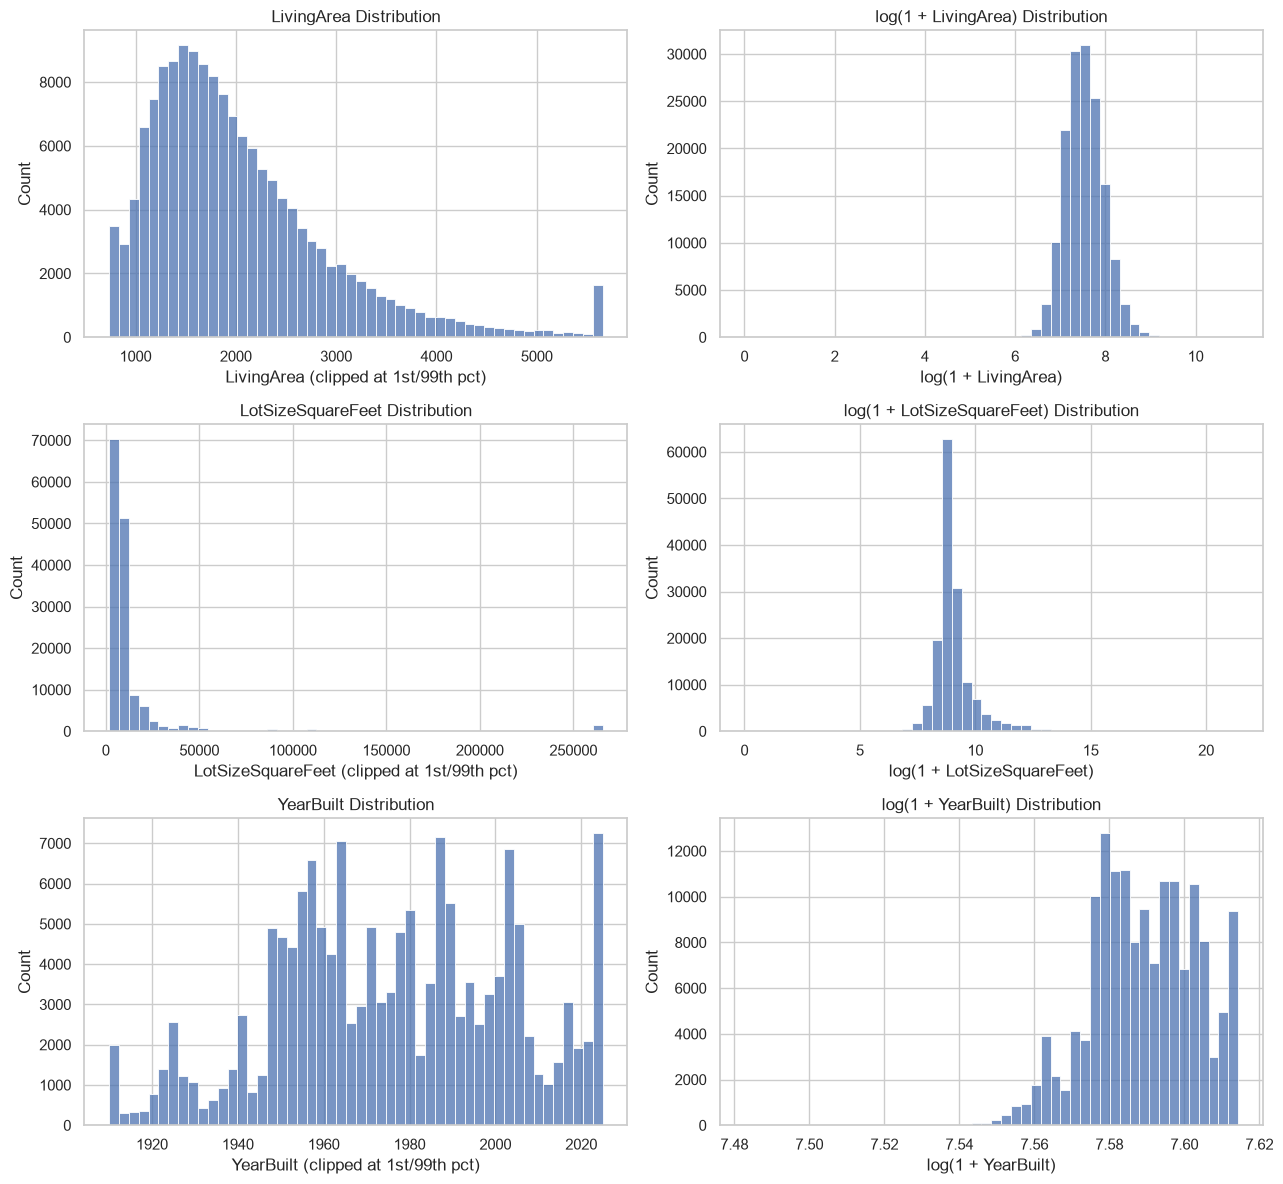

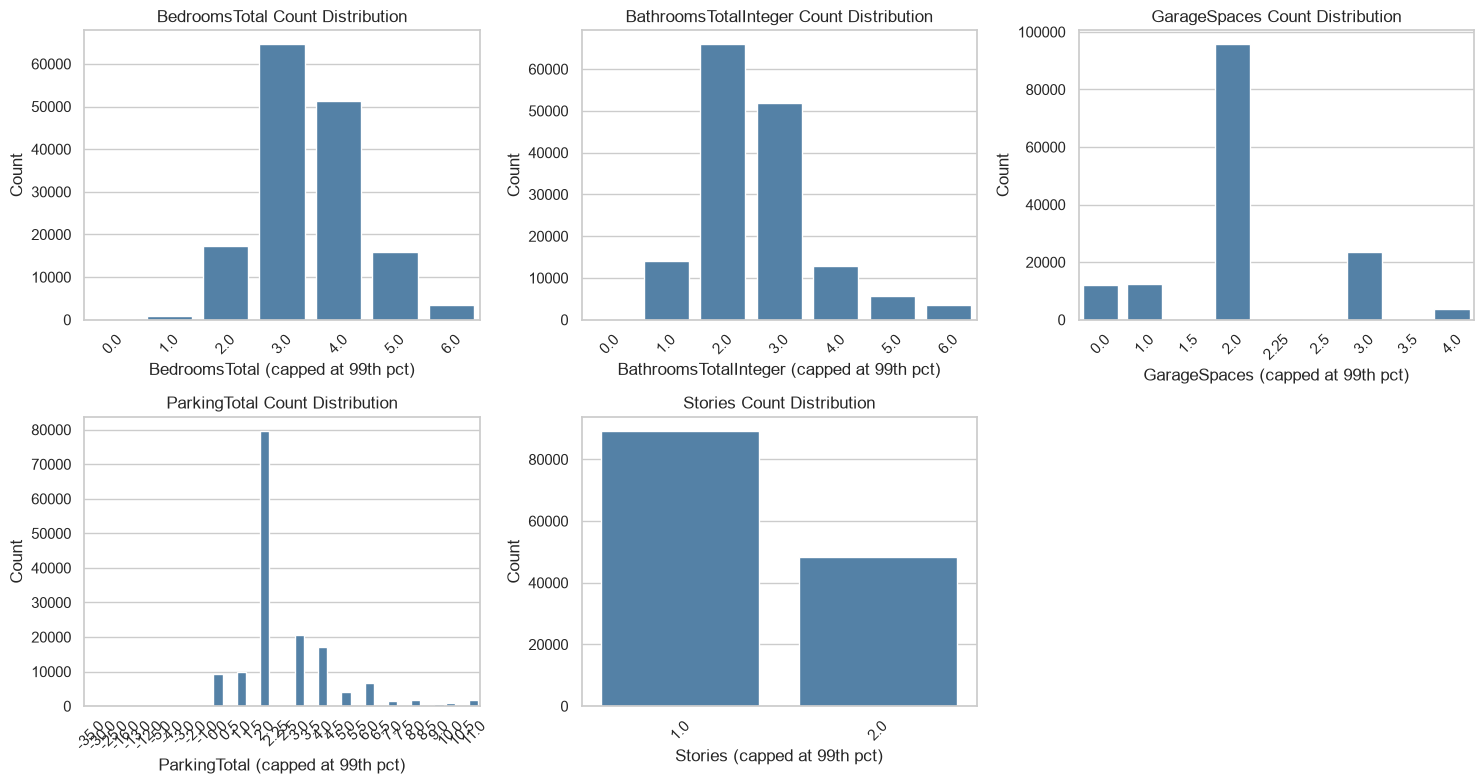

In [55]:
# Plot continuous and count numeric features separately.
# Continuous variables are shown with original and log-scale histograms.
core_continuous_plot_cols = ["LivingArea", "LotSizeSquareFeet", "YearBuilt"]
core_continuous_plot_cols = [col for col in core_continuous_plot_cols if col in df.columns]

fig, axes = plt.subplots(len(core_continuous_plot_cols), 2, figsize=(13, 4 * len(core_continuous_plot_cols)))

for i, col in enumerate(core_continuous_plot_cols):
    values = df[col].dropna()

    # Clip the original-scale histogram only for readability.
    # The raw values remain unchanged in df.
    lower = values.quantile(0.01)
    upper = values.quantile(0.99)
    clipped_values = values.clip(lower, upper)

    sns.histplot(clipped_values, bins=50, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} Distribution")
    axes[i, 0].set_xlabel(f"{col} (clipped at 1st/99th pct)")
    axes[i, 0].set_ylabel("Count")

    # Log histogram is useful for right-skewed non-negative continuous variables.
    non_negative_values = values[values >= 0]
    sns.histplot(np.log1p(non_negative_values), bins=50, ax=axes[i, 1])
    axes[i, 1].set_title(f"log(1 + {col}) Distribution")
    axes[i, 1].set_xlabel(f"log(1 + {col})")
    axes[i, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# Count/ordinal variables are discrete, so bar charts are easier to interpret than log histograms.
core_count_plot_cols = [
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "GarageSpaces",
    "ParkingTotal",
    "Stories",
]
core_count_plot_cols = [col for col in core_count_plot_cols if col in df.columns]

n_cols = 3
n_rows = math.ceil(len(core_count_plot_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(core_count_plot_cols):
    # Cap the display at the 99th percentile so rare extreme count values do not stretch the x-axis.
    cap = df[col].quantile(0.99)
    plot_values = df[col].clip(upper=cap)
    order = sorted(plot_values.dropna().unique())

    sns.countplot(x=plot_values, order=order, ax=axes[i], color="steelblue")
    axes[i].set_title(f"{col} Count Distribution")
    axes[i].set_xlabel(f"{col} (capped at 99th pct)")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(len(core_count_plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Categorical Feature Summary

In [56]:
# Summarize categorical columns by cardinality, missingness, and most common category.
# This informs encoding choices for preprocessing.
cat_summary = []

for col in categorical_cols:
    if col in df.columns:
        top_values = df[col].value_counts(dropna=False).head(5)
        cat_summary.append({
            "column": col,
            "n_unique": df[col].nunique(dropna=True),
            "missing_rate": df[col].isna().mean(),
            "top_value": top_values.index[0],
            "top_value_count": top_values.iloc[0],
            "top_5_values": ", ".join(map(str, top_values.index.tolist())),
        })

cat_summary_df = pd.DataFrame(cat_summary).sort_values("n_unique", ascending=False)
display(cat_summary_df)

# Show compact top-category tables for the most useful location/category fields.
# This is easier to interpret than plotting every categorical variable.
for col in ["CountyOrParish", "City", "PostalCode", "MLSAreaMajor"]:
    if col in df.columns:
        print(f"\nTop 10 values for {col}")
        display(df[col].value_counts(dropna=False).head(10).to_frame("count"))

,column,n_unique,missing_rate,top_value,top_value_count,top_5_values
2,PostalCode,2236,0.000013,92253,1104,"92253, 92345, 92584, 92223, 92592"
3,MLSAreaMajor,1038,0.146253,NaN,22505,"nan, 699 - Not Defined, SRCAR - Southwest Rive..."
0,City,1027,0.000370,Los Angeles,6426,"Los Angeles, San Diego, Riverside, San Jose, O..."
6,HighSchoolDistrict,428,0.269871,NaN,41527,"nan, Los Angeles Unified, Other, Capistrano Un..."
5,Flooring,282,0.356304,NaN,54827,"nan, Carpet,Tile, Wood, Tile,Wood, Laminate"
1,CountyOrParish,60,0.000000,Los Angeles,38404,"Los Angeles, Riverside, San Diego, San Bernard..."
4,Levels,18,0.072324,One,87992,"One, Two, nan, ThreeOrMore, MultiSplit"



Top 10 values for CountyOrParish


,count
CountyOrParish,
Los Angeles,38404
Riverside,23507
San Diego,16955
San Bernardino,16598
Orange,14795
Alameda,7362
Contra Costa,7279
Ventura,5065
Santa Clara,4403



Top 10 values for City


,count
City,
Los Angeles,6426
San Diego,5284
Riverside,2347
San Jose,2181
Oakland,1965
Menifee,1758
Long Beach,1561
Lancaster,1446
Murrieta,1407



Top 10 values for PostalCode


,count
PostalCode,
92253,1104
92345,922
92584,864
92223,823
92592,815
92596,797
92562,747
92211,714
93536,666



Top 10 values for MLSAreaMajor


,count
MLSAreaMajor,
NaN,22505
699 - Not Defined,13051
SRCAR - Southwest Riverside County,8558
252 - Riverside,2354
LAC - Lancaster,1424
263 - Banning/Beaumont/Cherry Valley,1357
VIC - Victorville,1319
248 - Corona,1304
274 - San Bernardino,1297


### PostalCode Format Check

Some ZIP codes may include ZIP+4 extensions or mixed formatting. This EDA check only summarizes the format; final standardization should happen in the preprocessing notebook.

In [57]:
# Check PostalCode formatting before preprocessing.
# The goal is only to identify mixed formats here; final conversion should happen in 02_preprocessing.
if "PostalCode" in df.columns:
    postal = df["PostalCode"].astype("string").str.strip()

    postal_format_summary = (
        pd.DataFrame(
            {
                "length": postal.str.len(),
                "has_hyphen": postal.str.contains("-", na=False),
                "is_missing": postal.isna() | postal.eq(""),
            }
        )
        .value_counts(dropna=False)
        .reset_index(name="count")
        .sort_values(["is_missing", "has_hyphen", "length"], ascending=[False, False, True])
    )

    display(postal_format_summary)

    # Extract the first 5-digit ZIP code for quick EDA checks only.
    # Do not treat this as final cleaning; reproduce the rule in preprocessing.
    df["PostalCode5"] = postal.str.extract(r"(\d{5})", expand=False)

    print(f"Rows with missing PostalCode5 after extraction: {df['PostalCode5'].isna().sum():,}")
else:
    print("PostalCode column is not available.")

,length,has_hyphen,is_missing,count
4,<NA>,False,True,2
2,7,True,False,3
5,8,True,False,1
3,9,True,False,3
1,10,True,False,823
0,5,False,False,153045


Rows with missing PostalCode5 after extraction: 2


### Location Summary

In [58]:
# County-level summary combines sample size and price level.
# This confirms that geography is likely a major predictor of ClosePrice.
county_summary = (
    df.dropna(subset=["CountyOrParish", "ClosePrice"])
    .groupby("CountyOrParish")
    .agg(
        n_sales=("ClosePrice", "size"),
        median_close_price=("ClosePrice", "median"),
        mean_close_price=("ClosePrice", "mean"),
    )
    .sort_values("n_sales", ascending=False)
)

print("Counties with the most sales")
display(county_summary.head(15))

print("Counties with the highest median ClosePrice, minimum 50 sales")
display(
    county_summary
    .query("n_sales >= 50")
    .sort_values("median_close_price", ascending=False)
    .head(15)
)

Counties with the most sales


,n_sales,median_close_price,mean_close_price
CountyOrParish,,,
Los Angeles,38404,1015264.5,1.548242e+06
Riverside,23507,630000.0,8.001011e+05
San Diego,16955,1060000.0,1.914778e+06
San Bernardino,16598,546950.0,6.364733e+05
Orange,14795,1400000.0,1.910685e+06
Alameda,7362,1300000.0,1.442972e+06
Contra Costa,7279,900000.0,1.308363e+06
Ventura,5065,970000.0,1.217819e+06
Santa Clara,4403,1900000.0,2.316439e+06


Counties with the highest median ClosePrice, minimum 50 sales


,n_sales,median_close_price,mean_close_price
CountyOrParish,,,
San Mateo,2160,2100000.0,2.603039e+06
Santa Clara,4403,1900000.0,2.316439e+06
Orange,14795,1400000.0,1.910685e+06
Santa Cruz,1014,1350000.0,1.538683e+06
San Francisco,241,1350000.0,1.523048e+06
Alameda,7362,1300000.0,1.442972e+06
Marin,53,1298000.0,1.510460e+06
San Diego,16955,1060000.0,1.914778e+06
Los Angeles,38404,1015264.5,1.548242e+06


In [59]:
# ZIP code is more granular than county but has high cardinality.
# Use a minimum sales threshold so the ranking is not dominated by tiny samples.
zip_summary = (
    df.dropna(subset=["PostalCode", "ClosePrice"])
    .groupby("PostalCode")
    .agg(
        n_sales=("ClosePrice", "size"),
        median_close_price=("ClosePrice", "median"),
    )
    .sort_values("n_sales", ascending=False)
)

print("ZIP codes with the most sales")
display(zip_summary.head(15))

print("ZIP codes with the highest median ClosePrice, minimum 30 sales")
display(
    zip_summary
    .query("n_sales >= 30")
    .sort_values("median_close_price", ascending=False)
    .head(15)
)

ZIP codes with the most sales


,n_sales,median_close_price
PostalCode,,
92253,1104,866500.0
92345,922,465000.0
92584,864,629600.0
92223,823,537000.0
92592,815,798000.0
92596,797,625000.0
92562,747,710000.0
92211,714,569250.0
93536,666,549000.0


ZIP codes with the highest median ClosePrice, minimum 30 sales


,n_sales,median_close_price
PostalCode,,
94027,37,8200000.0
93108,62,7136586.0
92657,87,7000000.0
92661,58,5835000.0
92625,134,5500000.0
90210,261,5425000.0
90402,126,5363402.5
94022,67,5300000.0
92662,32,5187500.0


# 5. Key features vs. Target variable

,pearson_corr,spearman_corr,missing_rate
LivingArea,0.114223,0.515612,0.000546
BathroomsTotalInteger,0.100650,0.477430,0.000104
BedroomsTotal,0.062582,0.371037,0.000000
Stories,0.026742,0.261904,0.104701
GarageSpaces,0.009219,0.246163,0.039623
Longitude,-0.006366,-0.241735,0.000091
AssociationFee,0.034026,0.214775,0.291501
ParkingTotal,0.000930,0.206684,0.000006
Latitude,-0.010353,-0.126610,0.000091
LotSizeSquareFeet,0.000458,0.104008,0.017254


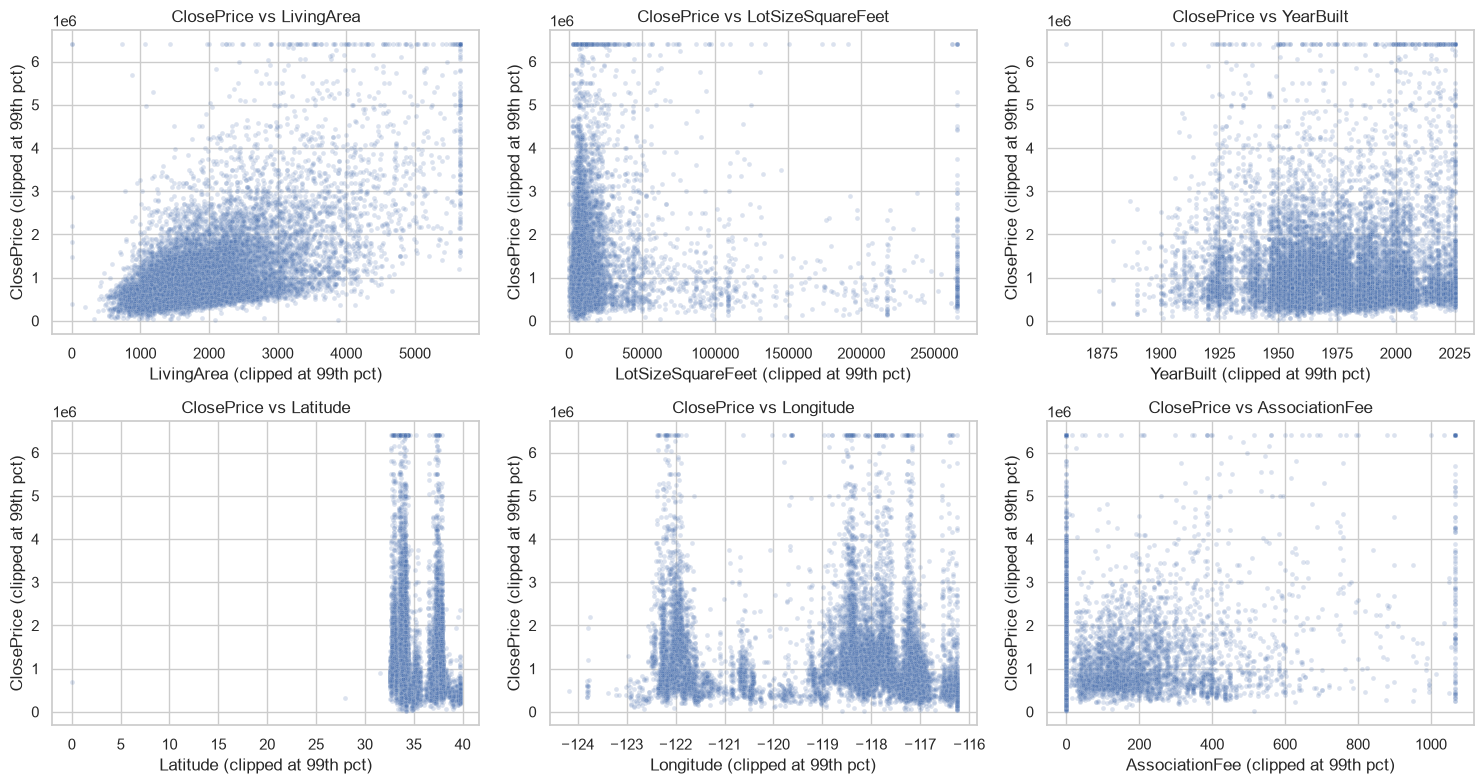

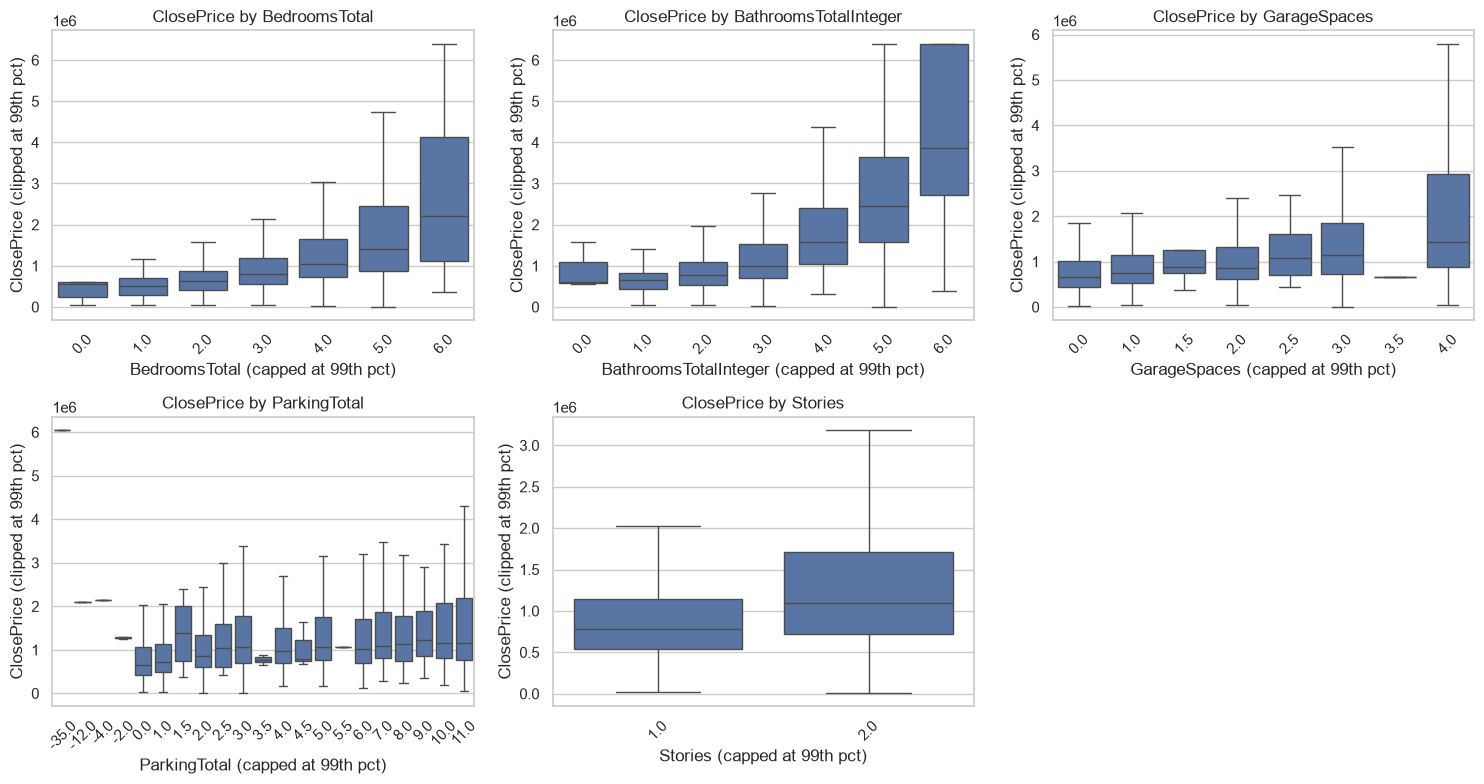

,feature_name,feature,n_sales,median_close_price
0,LivingArea,1000.0,15163,640000.0
1,LivingArea,1222.0,15014,735000.0
2,LivingArea,1396.0,15096,775000.0
3,LivingArea,1560.0,15061,810000.0
4,LivingArea,1729.0,15069,850000.0
5,LivingArea,1917.0,15081,900000.0
6,LivingArea,2143.0,15049,999999.0
7,LivingArea,2424.0,15075,1138000.0
8,LivingArea,2832.0,15049,1320000.0
9,LivingArea,3669.0,15061,2105000.0


In [60]:
# Define model-relevant numeric features to compare directly with the target.
# This section focuses on interpretable property characteristics and location fields.
key_features = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "GarageSpaces",
    "ParkingTotal",
    "Stories",
    "AssociationFee",
]

key_features = [col for col in key_features if col in df.columns]

# Build a numeric-only analysis frame for correlations and plots.
feature_target_df = df[["ClosePrice"] + key_features].copy()

for col in feature_target_df.columns:
    feature_target_df[col] = pd.to_numeric(feature_target_df[col], errors="coerce")

# Keep only positive target values for target-feature relationship checks.
feature_target_df = feature_target_df[feature_target_df["ClosePrice"].gt(0)].copy()

# Compare Pearson and Spearman correlations.
# Spearman is often more useful in EDA because it captures monotonic relationships and is less sensitive to scale.
corr_summary = pd.DataFrame(
    {
        "pearson_corr": feature_target_df.corr(numeric_only=True)["ClosePrice"],
        "spearman_corr": feature_target_df.corr(method="spearman", numeric_only=True)["ClosePrice"],
        "missing_rate": feature_target_df.isna().mean(),
    }
).drop(index="ClosePrice")

corr_summary["abs_spearman_corr"] = corr_summary["spearman_corr"].abs()
corr_summary = corr_summary.sort_values("abs_spearman_corr", ascending=False)

display(corr_summary.drop(columns="abs_spearman_corr"))

# Use clipping and sampling for readable, fast plots. This affects plots only, not the raw data.
plot_df = feature_target_df.sample(
    n=min(15000, len(feature_target_df)),
    random_state=42,
).copy()

price_upper = feature_target_df["ClosePrice"].quantile(0.99)
plot_df["ClosePrice_clipped"] = plot_df["ClosePrice"].clip(upper=price_upper)

# Continuous features are shown with scatter plots.
continuous_features = [
    "LivingArea",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "AssociationFee",
]
continuous_features = [col for col in continuous_features if col in key_features]

n_cols = 3
n_rows = math.ceil(len(continuous_features) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(continuous_features):
    # Clip x values only in the plot so extreme values do not hide the main relationship.
    x_upper = feature_target_df[col].quantile(0.99)
    x_values = plot_df[col].clip(upper=x_upper)

    sns.scatterplot(
        x=x_values,
        y=plot_df["ClosePrice_clipped"],
        alpha=0.2,
        s=12,
        ax=axes[i],
    )
    axes[i].set_title(f"ClosePrice vs {col}")
    axes[i].set_xlabel(f"{col} (clipped at 99th pct)")
    axes[i].set_ylabel("ClosePrice (clipped at 99th pct)")

for j in range(len(continuous_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Discrete/count-like features are shown with boxplots.
discrete_features = [
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "GarageSpaces",
    "ParkingTotal",
    "Stories",
]
discrete_features = [col for col in discrete_features if col in key_features]

n_cols = 3
n_rows = math.ceil(len(discrete_features) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(discrete_features):
    temp = plot_df[[col, "ClosePrice_clipped"]].dropna().copy()
    cap = feature_target_df[col].quantile(0.99)
    temp[col] = temp[col].clip(upper=cap)

    sns.boxplot(data=temp, x=col, y="ClosePrice_clipped", ax=axes[i], showfliers=False)
    axes[i].set_title(f"ClosePrice by {col}")
    axes[i].set_xlabel(f"{col} (capped at 99th pct)")
    axes[i].set_ylabel("ClosePrice (clipped at 99th pct)")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(len(discrete_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Bin skewed continuous features into deciles and compare median target by bin.
# This makes nonlinear relationships easier to read than a dense scatter plot.
binned_features = ["LivingArea", "LotSizeSquareFeet", "YearBuilt"]
binned_features = [col for col in binned_features if col in key_features]

binned_summaries = []

for col in binned_features:
    temp = feature_target_df[[col, "ClosePrice"]].dropna().copy()
    temp = temp[temp[col].between(temp[col].quantile(0.01), temp[col].quantile(0.99))]
    temp["bin"] = pd.qcut(temp[col], q=10, duplicates="drop")

    summary = (
        temp.groupby("bin", observed=True)
        .agg(
            feature=(col, "median"),
            n_sales=("ClosePrice", "size"),
            median_close_price=("ClosePrice", "median"),
        )
        .reset_index(drop=True)
    )
    summary.insert(0, "feature_name", col)
    binned_summaries.append(summary)

binned_summary_df = pd.concat(binned_summaries, ignore_index=True)
display(binned_summary_df)

# 6. Additional EDA Checks

These checks focus on model-relevant relationships and data quality questions that should be resolved before preprocessing/modeling.

### Price per Square Foot

`ClosePrice / LivingArea` is useful for comparing properties with different sizes. It should only be computed when both `ClosePrice` and `LivingArea` are positive.

EDA only, not a model feature

,PricePerSqFt
count,1.537210e+05
mean,6.613277e+02
std,6.002525e+03
min,4.981497e-04
1%,1.678672e+02
5%,2.233077e+02
25%,3.464347e+02
50%,5.305100e+02
75%,7.423756e+02
95%,1.250000e+03


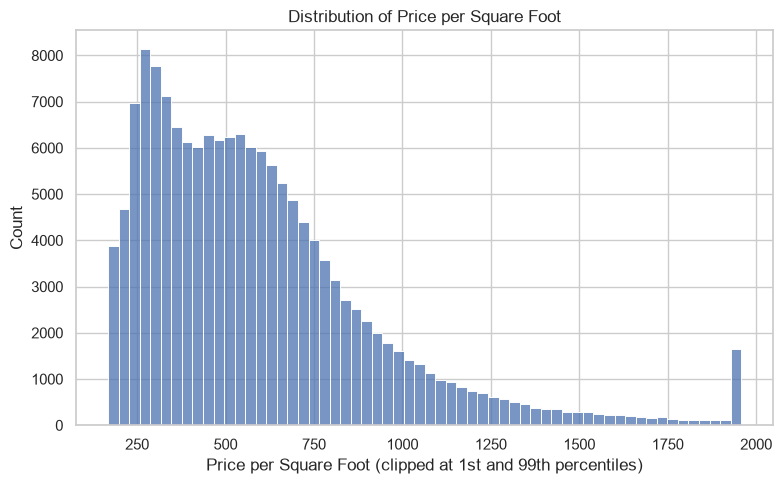

In [61]:
# Create a normalized price metric so properties of different sizes can be compared.
# Only compute this when both ClosePrice and LivingArea are positive; otherwise set it to NaN.
df["PricePerSqFt"] = np.where(
    (df["ClosePrice"] > 0) & (df["LivingArea"] > 0),
    df["ClosePrice"] / df["LivingArea"],
    np.nan,
)

# Summarize the full distribution, including tail percentiles.
# The 1st and 99th percentiles help identify suspiciously low/high price-per-sq-ft values.
price_per_sqft_summary = df["PricePerSqFt"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

display(price_per_sqft_summary.to_frame("PricePerSqFt"))

# Clip only for visualization so extreme values do not make the histogram unreadable.
# This does not change df["PricePerSqFt"] or remove any rows from the dataset.
psf_lower = df["PricePerSqFt"].quantile(0.01)
psf_upper = df["PricePerSqFt"].quantile(0.99)

plt.figure(figsize=(8, 5))
sns.histplot(df["PricePerSqFt"].clip(psf_lower, psf_upper), bins=60)
plt.xlabel("Price per Square Foot (clipped at 1st and 99th percentiles)")
plt.ylabel("Count")
plt.title("Distribution of Price per Square Foot")
plt.tight_layout()
plt.show()

,n_sales,median_price_per_sqft,median_close_price
CountyOrParish,,,
San Mateo,2160,1190.476190,2100000.0
Santa Clara,4403,1087.737301,1900000.0
San Francisco,238,921.819834,1345000.0
Marin,53,782.828283,1298000.0
Santa Cruz,1014,754.584647,1350000.0
Alameda,7358,738.873936,1300000.0
Orange,14795,716.343490,1400000.0
Los Angeles,38289,635.439361,1015000.0
San Diego,16953,599.086236,1060000.0


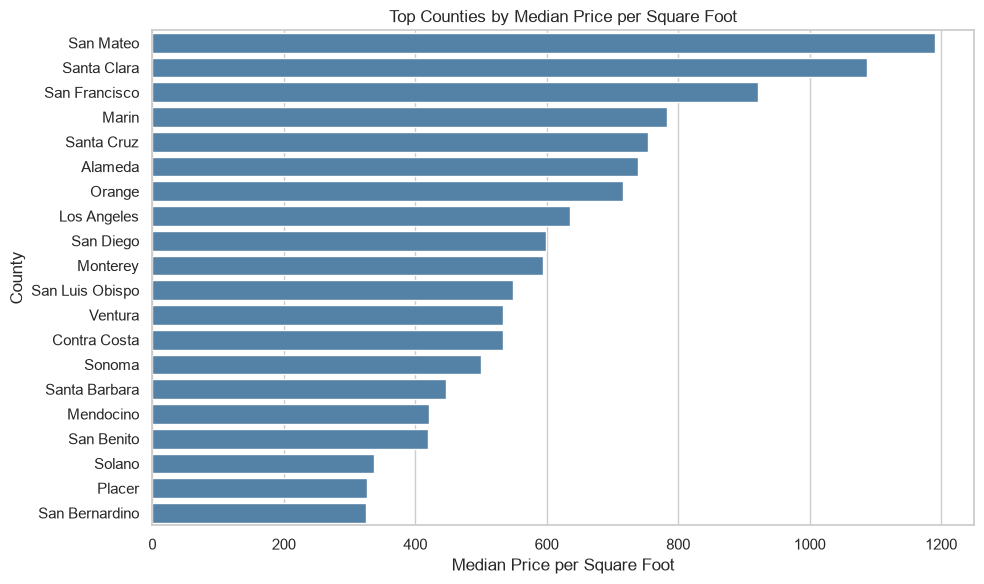

In [62]:
# Compare price per square foot by county.
# Require at least 50 sales so the ranking is not driven by counties with only a few records.
psf_by_county = (
    df.dropna(subset=["CountyOrParish", "PricePerSqFt"])
    .groupby("CountyOrParish")
    .agg(
        n_sales=("PricePerSqFt", "size"),
        median_price_per_sqft=("PricePerSqFt", "median"),
        median_close_price=("ClosePrice", "median"),
    )
    .query("n_sales >= 50")
    .sort_values("median_price_per_sqft", ascending=False)
)

# Display the most expensive counties on a size-adjusted basis.
display(psf_by_county.head(20))

# Plot the same ranking so regional differences are easier to scan visually.
plt.figure(figsize=(10, 6))
sns.barplot(
    data=psf_by_county.head(20).reset_index(),
    y="CountyOrParish",
    x="median_price_per_sqft",
    color="steelblue",
)
plt.xlabel("Median Price per Square Foot")
plt.ylabel("County")
plt.title("Top Counties by Median Price per Square Foot")
plt.tight_layout()
plt.show()

### Boolean / Amenity Feature Summary

Amenity variables can be associated with higher prices, but the relationship may be confounded by home size and location. Median `PricePerSqFt` gives a size-adjusted quick check.

In [63]:
# Compact summary for boolean / amenity features.
# This checks both median ClosePrice and median PricePerSqFt by True/False/Missing status.
if "PricePerSqFt" not in df.columns:
    df["PricePerSqFt"] = np.where(
        (df["ClosePrice"] > 0) & (df["LivingArea"] > 0),
        df["ClosePrice"] / df["LivingArea"],
        np.nan,
    )

boolean_summary = []

for col in boolean_cols:
    if col not in df.columns:
        continue

    temp = df[[col, "ClosePrice", "PricePerSqFt"]].copy()

    # Normalize common boolean encodings to True / False / Missing.
    status = temp[col].astype("string").str.strip().str.lower()
    temp["status"] = status.map(
        {
            "true": "True",
            "false": "False",
            "1": "True",
            "0": "False",
            "yes": "True",
            "no": "False",
            "y": "True",
            "n": "False",
        }
    ).fillna("Missing")

    summary = (
        temp.groupby("status")
        .agg(
            n=("ClosePrice", "size"),
            median_close_price=("ClosePrice", "median"),
            median_price_per_sqft=("PricePerSqFt", "median"),
        )
        .reset_index()
    )
    summary["share"] = summary["n"] / summary["n"].sum()
    summary.insert(0, "feature", col)
    boolean_summary.append(summary)

if boolean_summary:
    boolean_summary_df = pd.concat(boolean_summary, ignore_index=True)
    display(boolean_summary_df)
else:
    print("No boolean amenity columns are available.")

,feature,status,n,median_close_price,median_price_per_sqft,share
0,ViewYN,False,53415,865000.0,560.278207,0.347128
1,ViewYN,Missing,13966,940000.0,600.516633,0.090761
2,ViewYN,True,86496,905000.0,498.497391,0.562111
3,PoolPrivateYN,False,118009,825000.0,512.315271,0.766905
4,PoolPrivateYN,Missing,11911,1725000.0,934.782609,0.077406
5,PoolPrivateYN,True,23957,1136250.0,504.821327,0.155689
6,AttachedGarageYN,False,22368,880000.0,638.130252,0.145363
7,AttachedGarageYN,Missing,18679,901000.0,583.333333,0.121389
8,AttachedGarageYN,True,112830,895000.0,497.564370,0.733248
9,FireplaceYN,False,41753,715000.0,498.136634,0.271340


### County and City Median Price

Use a minimum sales threshold so small cities/counties do not dominate the ranking because of a few unusual transactions.

In [64]:
# Summarize median sale price by county and city.
# n_sales is kept in the table so we can judge whether each median is based on enough data.
county_price_summary = (
    df.dropna(subset=["CountyOrParish", "ClosePrice"])
    .groupby("CountyOrParish")
    .agg(
        n_sales=("ClosePrice", "size"),
        median_close_price=("ClosePrice", "median"),
        median_price_per_sqft=("PricePerSqFt", "median"),
    )
    .query("n_sales >= 50")
    .sort_values("median_close_price", ascending=False)
)

# City has higher cardinality than county, so the minimum sales threshold is especially important here.
city_price_summary = (
    df.dropna(subset=["City", "ClosePrice"])
    .groupby("City")
    .agg(
        n_sales=("ClosePrice", "size"),
        median_close_price=("ClosePrice", "median"),
        median_price_per_sqft=("PricePerSqFt", "median"),
    )
    .query("n_sales >= 50")
    .sort_values("median_close_price", ascending=False)
)

# Show the top rows from both summaries before plotting.
display(county_price_summary.head(20))
display(city_price_summary.head(20))

,n_sales,median_close_price,median_price_per_sqft
CountyOrParish,,,
San Mateo,2160,2100000.0,1190.476190
Santa Clara,4403,1900000.0,1087.737301
Orange,14795,1400000.0,716.343490
Santa Cruz,1014,1350000.0,754.584647
San Francisco,241,1350000.0,921.819834
Alameda,7362,1300000.0,738.873936
Marin,53,1298000.0,782.828283
San Diego,16955,1060000.0,599.086236
Los Angeles,38404,1015264.5,635.439361


,n_sales,median_close_price,median_price_per_sqft
City,,,
Newport Coast,87,7000000.0,1645.547342
Hillsborough,65,5500000.0,1557.377049
Corona Del Mar,132,5499000.0,2024.624718
Los Altos,119,4975000.0,1912.013536
Rancho Santa Fe,201,4750000.0,965.421504
Malibu,141,4600000.0,1312.029098
Beverly Hills,317,4565000.0,1264.963473
Newport Beach,514,4251250.0,1628.404122
Saratoga,134,4175000.0,1553.762511


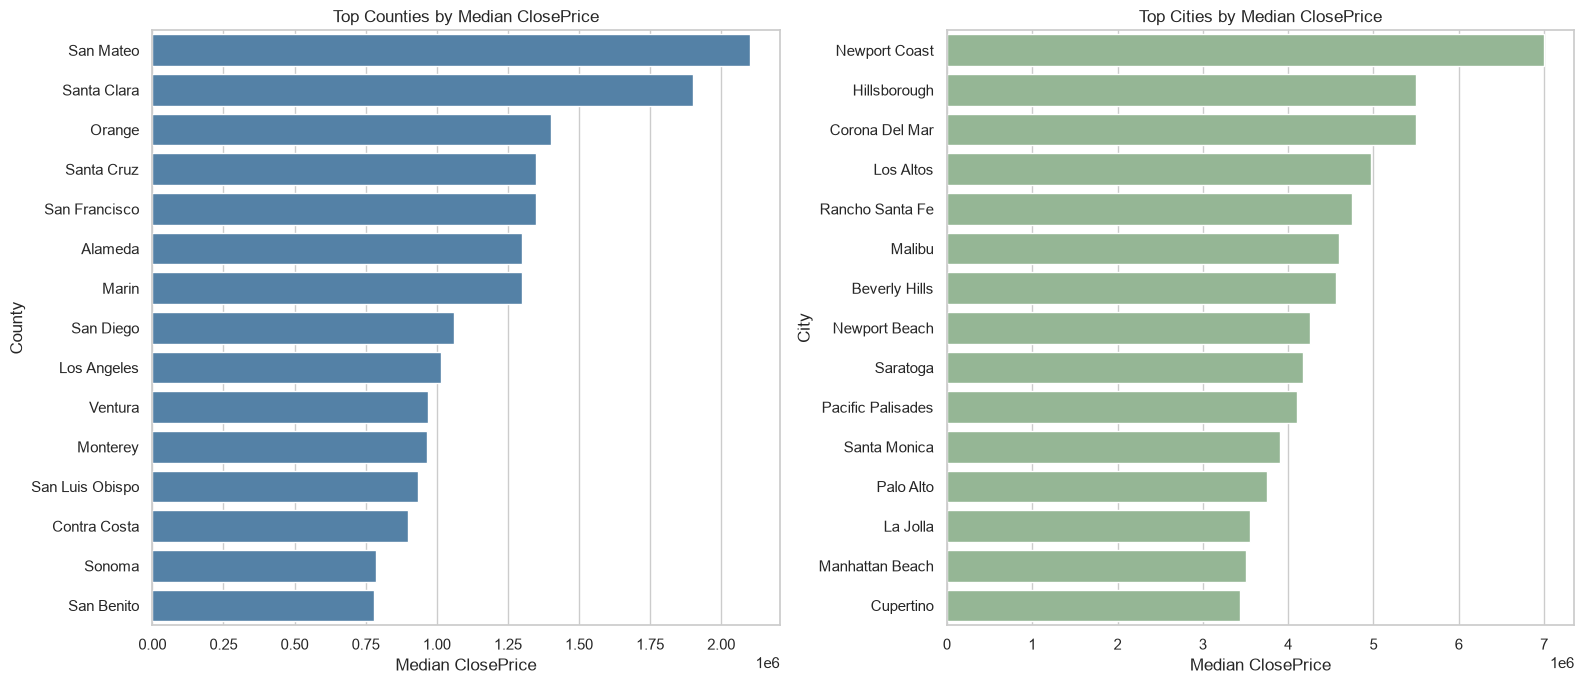

In [65]:
# Plot county and city medians side by side.
# These charts help identify high-price regions that may need strong geographic features in the model.
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(
    data=county_price_summary.head(15).reset_index(),
    y="CountyOrParish",
    x="median_close_price",
    color="steelblue",
    ax=axes[0],
)
axes[0].set_title("Top Counties by Median ClosePrice")
axes[0].set_xlabel("Median ClosePrice")
axes[0].set_ylabel("County")

sns.barplot(
    data=city_price_summary.head(15).reset_index(),
    y="City",
    x="median_close_price",
    color="darkseagreen",
    ax=axes[1],
)
axes[1].set_title("Top Cities by Median ClosePrice")
axes[1].set_xlabel("Median ClosePrice")
axes[1].set_ylabel("City")

plt.tight_layout()
plt.show()

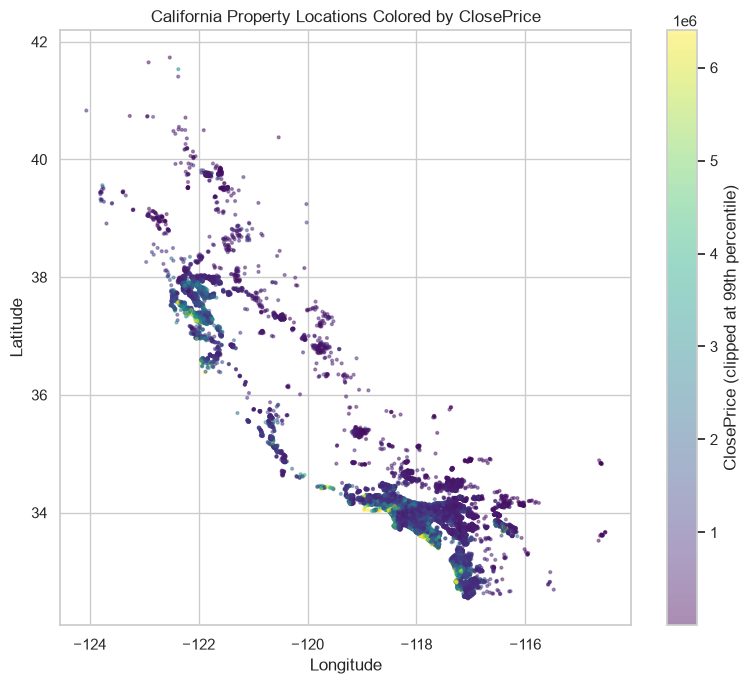

In [66]:
# Build a map-ready sample with valid coordinates and target values.
# The California bounds remove obvious coordinate errors before plotting.
map_sample = df.dropna(subset=["Latitude", "Longitude", "ClosePrice"]).copy()
map_sample = map_sample[
    map_sample["Latitude"].between(32.0, 42.5)
    & map_sample["Longitude"].between(-125.0, -114.0)
]

# Sample the rows so the scatter plot stays responsive in the notebook.
map_sample = map_sample.sample(n=min(20000, len(map_sample)), random_state=42)

# Clip color values only for visualization; otherwise a few luxury sales dominate the color scale.
map_sample["ClosePrice_clipped"] = map_sample["ClosePrice"].clip(
    upper=df["ClosePrice"].quantile(0.99)
)

plt.figure(figsize=(8, 7))
scatter = plt.scatter(
    map_sample["Longitude"],
    map_sample["Latitude"],
    c=map_sample["ClosePrice_clipped"],
    s=4,
    alpha=0.45,
    cmap="viridis",
)
plt.colorbar(scatter, label="ClosePrice (clipped at 99th percentile)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Property Locations Colored by ClosePrice")
plt.tight_layout()
plt.show()

### Time Coverage and Future Test Set


In [67]:
# Convert important date fields to datetime.
# These fields help us understand time coverage and identify potential leakage columns.
date_cols = [
    "CloseDate",
    "ListingContractDate",
    "PurchaseContractDate",
    "ContractStatusChangeDate",
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Check date ranges for each available date column.
# CloseDate defines the chronological split; later transaction dates may be leakage for modeling.
available_date_cols = [col for col in date_cols if col in df.columns]
date_range_summary = df[available_date_cols].agg(["min", "max"]).T

display(date_range_summary)

# Create a monthly close period for trend analysis and future train/test splitting.
df["CloseMonth"] = df["CloseDate"].dt.to_period("M").astype("string")

# Summarize monthly sample size and price levels.
# This helps decide whether the latest month is large enough and stable enough to use as a test set.
monthly_summary = (
    df.dropna(subset=["CloseMonth"])
    .groupby("CloseMonth")
    .agg(
        n_sales=("ClosePrice", "size"),
        median_close_price=("ClosePrice", "median"),
        mean_close_price=("ClosePrice", "mean"),
        median_price_per_sqft=("PricePerSqFt", "median"),
    )
    .reset_index()
    .sort_values("CloseMonth")
)

latest_month = monthly_summary["CloseMonth"].iloc[-1]
latest_month_rows = int(monthly_summary.loc[monthly_summary["CloseMonth"] == latest_month, "n_sales"].iloc[0])

print(f"Latest month available: {latest_month}")
print(f"Rows in latest month: {latest_month_rows:,}")

# Show recent months only to keep the train/test split decision focused.
display(monthly_summary.tail(18))

,min,max
CloseDate,2025-04-01,2026-05-31
ListingContractDate,2014-12-16,2026-05-30
PurchaseContractDate,2020-08-18,2026-05-30
ContractStatusChangeDate,2025-04-01,2026-05-31


Latest month available: 2026-05
Rows in latest month: 12,024


,CloseMonth,n_sales,median_close_price,mean_close_price,median_price_per_sqft
0,2025-04,11880,900000.0,1.357640e+06,544.054925
1,2025-05,11777,905000.0,1.333889e+06,542.954930
2,2025-06,11701,910000.0,1.372109e+06,538.758915
3,2025-07,12114,896000.0,1.313660e+06,534.126953
4,2025-08,11454,885500.0,1.237614e+06,526.810913
5,2025-09,11456,880000.0,1.508458e+06,528.142978
6,2025-10,12029,888163.0,1.333730e+06,526.485788
7,2025-11,9739,875000.0,1.338764e+06,519.858505
8,2025-12,10455,860000.0,1.195244e+06,510.582011
9,2026-01,7490,851691.5,1.280369e+06,498.734705


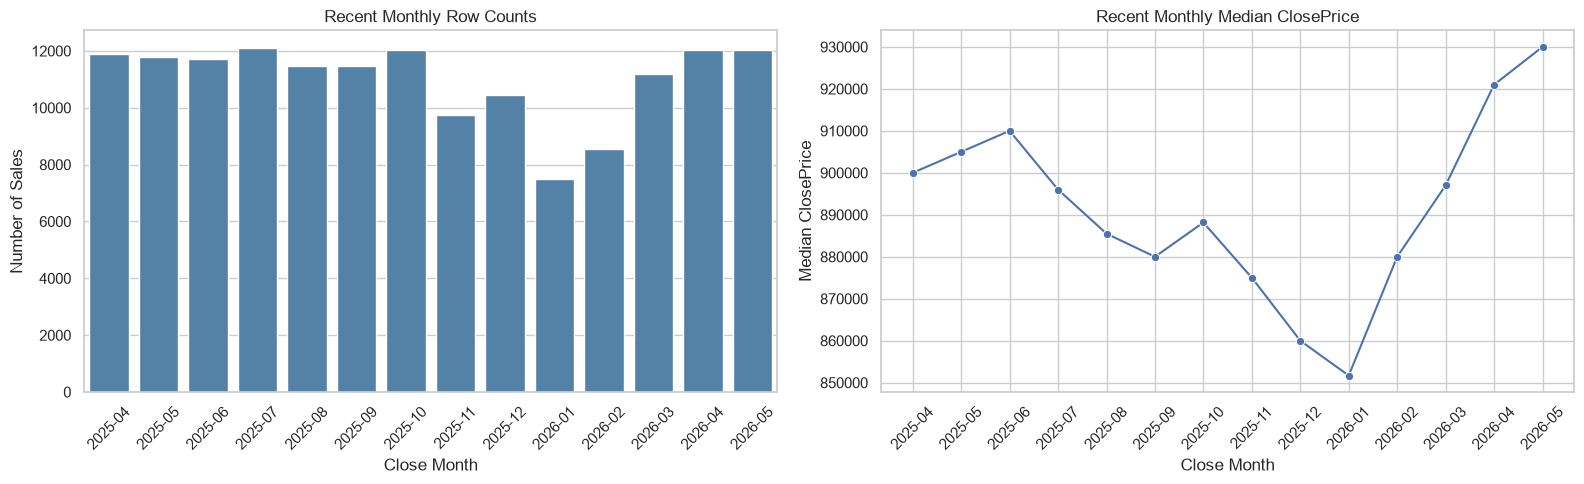

In [68]:
# Plot recent monthly sales volume and median price together.
# A sharp drop in the latest month could mean the month is incomplete and should not be used as test data.
recent_months = monthly_summary.tail(18)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=recent_months, x="CloseMonth", y="n_sales", color="steelblue", ax=axes[0])
axes[0].set_title("Recent Monthly Row Counts")
axes[0].set_xlabel("Close Month")
axes[0].set_ylabel("Number of Sales")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=recent_months, x="CloseMonth", y="median_close_price", marker="o", ax=axes[1])
axes[1].set_title("Recent Monthly Median ClosePrice")
axes[1].set_xlabel("Close Month")
axes[1].set_ylabel("Median ClosePrice")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Date Order Sanity Check

Check whether key transaction dates follow a reasonable order. These checks are only diagnostic here; row removal or correction should happen in preprocessing.


In [69]:
# Sanity check for chronological consistency between major transaction dates.
# Each comparison only uses rows where both columns are available, so missing dates do not count as violations.
date_order_checks = [
    ("ListingContractDate <= PurchaseContractDate", "ListingContractDate", "PurchaseContractDate"),
    ("PurchaseContractDate <= CloseDate", "PurchaseContractDate", "CloseDate"),
    ("ListingContractDate <= CloseDate", "ListingContractDate", "CloseDate"),
]

sanity_rows = []
violation_examples = []

for check_name, start_col, end_col in date_order_checks:
    if start_col not in df.columns or end_col not in df.columns:
        sanity_rows.append(
            {
                "check": check_name,
                "n_compared": 0,
                "n_violations": np.nan,
                "violation_rate": np.nan,
                "note": "missing required column",
            }
        )
        continue

    temp = df[["ListingKey", start_col, end_col, "ClosePrice", "City", "CountyOrParish"]].copy()
    temp[start_col] = pd.to_datetime(temp[start_col], errors="coerce")
    temp[end_col] = pd.to_datetime(temp[end_col], errors="coerce")

    comparable = temp[start_col].notna() & temp[end_col].notna()
    violations = comparable & (temp[start_col] > temp[end_col])
    n_compared = int(comparable.sum())
    n_violations = int(violations.sum())

    sanity_rows.append(
        {
            "check": check_name,
            "n_compared": n_compared,
            "n_violations": n_violations,
            "violation_rate": n_violations / n_compared if n_compared else np.nan,
            "note": "",
        }
    )

    if n_violations:
        example_cols = ["ListingKey", start_col, end_col, "ClosePrice", "City", "CountyOrParish"]
        examples = temp.loc[violations, example_cols].head(5).copy()
        examples.insert(0, "check", check_name)
        violation_examples.append(examples)

# DaysOnMarket should not be negative when it is available.
if "DaysOnMarket" in df.columns:
    dom = pd.to_numeric(df["DaysOnMarket"], errors="coerce")
    comparable = dom.notna()
    violations = comparable & (dom < 0)
    n_compared = int(comparable.sum())
    n_violations = int(violations.sum())

    sanity_rows.append(
        {
            "check": "DaysOnMarket >= 0",
            "n_compared": n_compared,
            "n_violations": n_violations,
            "violation_rate": n_violations / n_compared if n_compared else np.nan,
            "note": "",
        }
    )

    if n_violations:
        example_cols = [col for col in ["ListingKey", "DaysOnMarket", "CloseDate", "ClosePrice", "City", "CountyOrParish"] if col in df.columns]
        examples = df.loc[violations, example_cols].head(5).copy()
        examples.insert(0, "check", "DaysOnMarket >= 0")
        violation_examples.append(examples)
else:
    sanity_rows.append(
        {
            "check": "DaysOnMarket >= 0",
            "n_compared": 0,
            "n_violations": np.nan,
            "violation_rate": np.nan,
            "note": "missing required column",
        }
    )

date_sanity_summary = pd.DataFrame(sanity_rows)
display(date_sanity_summary)

# Display a small sample of problematic rows only if violations exist.
if violation_examples:
    date_violation_examples = pd.concat(violation_examples, ignore_index=True, sort=False)
    display(date_violation_examples)
else:
    print("No date order or negative DaysOnMarket violations found in these checks.")


,check,n_compared,n_violations,violation_rate,note
0,ListingContractDate <= PurchaseContractDate,153869,81,0.000526,
1,PurchaseContractDate <= CloseDate,153869,58,0.000377,
2,ListingContractDate <= CloseDate,153877,18,0.000117,
3,DaysOnMarket >= 0,153877,18,0.000117,


,check,ListingKey,ListingContractDate,PurchaseContractDate,ClosePrice,City,CountyOrParish,CloseDate,DaysOnMarket
0,ListingContractDate <= PurchaseContractDate,1111778465,2025-04-04,2025-04-01,2600000.0,La Jolla,San Diego,NaT,NaN
1,ListingContractDate <= PurchaseContractDate,1111674395,2025-03-19,2025-03-18,430000.0,Campo,San Diego,NaT,NaN
2,ListingContractDate <= PurchaseContractDate,1108347586,2025-03-13,2025-03-12,4050000.0,Los Angeles,Los Angeles,NaT,NaN
3,ListingContractDate <= PurchaseContractDate,1107775186,2025-04-11,2025-03-17,1645000.0,View Park,Los Angeles,NaT,NaN
4,ListingContractDate <= PurchaseContractDate,1107643296,2025-03-12,2025-03-10,2200000.0,Manhattan Beach,Los Angeles,NaT,NaN
5,PurchaseContractDate <= CloseDate,1112333757,NaT,2025-04-30,3550000.0,San Jose,Santa Clara,2025-04-02,NaN
6,PurchaseContractDate <= CloseDate,1112303888,NaT,2025-04-29,3700000.0,San Mateo,San Mateo,2025-04-28,NaN
7,PurchaseContractDate <= CloseDate,1112053877,NaT,2025-04-22,1280000.0,Santa Cruz,Santa Cruz,2025-04-21,NaN
8,PurchaseContractDate <= CloseDate,1111921394,NaT,2025-04-18,1000000.0,San Jose,Santa Clara,2025-04-17,NaN
9,PurchaseContractDate <= CloseDate,1111565092,NaT,2025-04-09,1900000.0,San Jose,Santa Clara,2025-04-07,NaN


### Extreme Values in Key Numeric Features

These rows help distinguish true luxury or unusual properties from likely data errors before modeling.

In [70]:
# Select identifying and model-relevant fields for inspecting extreme numeric values.
# These rows are for manual review only; no rows are removed in this EDA notebook.
extreme_check_cols = [
    "ListingKey",
    "source_file",
    "CloseDate",
    "ClosePrice",
    "LivingArea",
    "LotSizeSquareFeet",
    "YearBuilt",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "City",
    "CountyOrParish",
    "PostalCode",
]
extreme_check_cols = [col for col in extreme_check_cols if col in df.columns]

# Inspect both tails for key numeric fields.
# Low values can reveal placeholder or missing-data encodings; high values can be true luxury/outlier records.
for feature in ["LivingArea", "LotSizeSquareFeet", "YearBuilt"]:
    if feature not in df.columns:
        continue

    print(f"\nLowest {feature} values")
    display(
        df.dropna(subset=[feature])
        .sort_values(feature, ascending=True)
        .loc[:, extreme_check_cols]
        .head(10)
    )

    print(f"Highest {feature} values")
    display(
        df.dropna(subset=[feature])
        .sort_values(feature, ascending=False)
        .loc[:, extreme_check_cols]
        .head(10)
    )


Lowest LivingArea values


,ListingKey,source_file,CloseDate,ClosePrice,LivingArea,LotSizeSquareFeet,YearBuilt,BedroomsTotal,BathroomsTotalInteger,City,CountyOrParish,PostalCode
24516,1112905774,CRMLSSold202505.csv,2025-05-07,2125390.0,0.0,9331.0,NaN,0.0,0.0,Rancho Mirage,Riverside,92270
47350,1115087921,CRMLSSold202506.csv,2025-06-23,925000.0,0.0,12362.0,1968.0,0.0,0.0,Pasadena,Los Angeles,91107
202019,1150723609,CRMLSSold202601.csv,2026-01-23,650000.0,0.0,4797.0,1925.0,0.0,0.0,San Diego,San Diego,92104
206005,1147468485,CRMLSSold202601.csv,2026-01-16,540000.0,0.0,5457.0,1942.0,3.0,1.0,San Pablo,Contra Costa,94806
250876,1150504103,CRMLSSold202603.csv,2026-03-26,1470000.0,0.0,2249.0,1910.0,2.0,1.0,Venice,Los Angeles,90291
194705,1134702110,CRMLSSold202512.csv,2025-12-22,1920000.0,0.0,11731.0,1967.0,3.0,3.0,Los Angeles,Los Angeles,90049
160541,1109276644,CRMLSSold202510.csv,2025-10-15,678821.0,0.0,4491.0,NaN,0.0,0.0,Palm Desert,Riverside,92211
158863,1114526676,CRMLSSold202510.csv,2025-10-09,876838.0,0.0,13939.0,NaN,0.0,0.0,Bakersfield,Kern,93311
31683,1111443101,CRMLSSold202505.csv,2025-05-30,570000.0,0.0,10850.0,1952.0,0.0,0.0,Altadena,Los Angeles,91001
281662,1108520884,CRMLSSold202604.csv,2026-04-01,2075000.0,0.0,262281.0,NaN,3.0,2.0,Malibu,Los Angeles,90265


Highest LivingArea values


,ListingKey,source_file,CloseDate,ClosePrice,LivingArea,LotSizeSquareFeet,YearBuilt,BedroomsTotal,BathroomsTotalInteger,City,CountyOrParish,PostalCode
92934,1032371159,CRMLSSold202507.csv,2025-07-31,110000000.0,56500.0,200449.0,1990.0,14.0,27.0,Los Angeles,Los Angeles,90024
180098,1108565800,CRMLSSold202511.csv,2025-11-14,28000000.0,31068.0,1697968.8,1996.0,19.0,23.0,Rancho Santa Fe,San Diego,92067
64937,1108476202,CRMLSSold202506.csv,2025-06-20,63100000.0,30500.0,267415.0,2014.0,12.0,20.0,Beverly Hills,Los Angeles,90210
305063,1048618285,CRMLSSold202605.csv,2026-05-15,21500000.0,23314.0,935669.0,2010.0,10.0,22.0,Alamo,Contra Costa,94507
91658,1103389607,CRMLSSold202507.csv,2025-07-28,19000000.0,20000.0,43560.0,2021.0,6.0,11.0,Malibu,Ventura,90265
133214,1115099459,CRMLSSold202509.csv,2025-09-19,44000000.0,20000.0,153862.0,2005.0,8.0,14.0,Los Angeles,Los Angeles,90049
68594,1090174200,CRMLSSold202506.csv,2025-06-12,13500000.0,20000.0,87599.0,1917.0,9.0,11.0,Los Angeles,Los Angeles,90027
244777,1152160462,CRMLSSold202603.csv,2026-03-25,30260000.0,19474.0,29589.0,2011.0,7.0,15.0,Beverly Hills,Los Angeles,90210
305004,1093899305,CRMLSSold202605.csv,2026-05-11,10380000.0,17230.0,116194.0,2024.0,10.0,16.0,Bradbury,Los Angeles,91008
234210,1127472951,CRMLSSold202602.csv,2026-02-27,8000000.0,17153.0,109771.2,2016.0,10.0,13.0,Bradbury,Los Angeles,91008



Lowest LotSizeSquareFeet values


...

,ListingKey,source_file,CloseDate,ClosePrice,LivingArea,LotSizeSquareFeet,YearBuilt,BedroomsTotal,BathroomsTotalInteger,City,CountyOrParish,PostalCode
164646,1141173096,CRMLSSold202511.csv,2025-11-10,2950000.0,2825.0,1.938943e+09,1987.0,4.0,4.0,Agoura,Los Angeles,91301
134305,1114598008,CRMLSSold202509.csv,2025-09-15,5500000.0,4943.0,1.897474e+09,2017.0,6.0,6.0,San Diego,San Diego,92127
255693,1139858671,CRMLSSold202603.csv,2026-03-09,419000.0,1990.0,1.897474e+09,1990.0,3.0,3.0,Mountain Center,Riverside,92561
233407,1135672298,CRMLSSold202602.csv,2026-02-27,2863000.0,3549.0,1.897474e+09,1971.0,5.0,4.0,Orange,Orange,92869
214408,1134287822,CRMLSSold202601.csv,2026-01-02,617500.0,3035.0,1.802600e+09,1977.0,5.0,3.0,Madera,Madera,93636
164304,1144194198,CRMLSSold202511.csv,2025-11-12,315000.0,912.0,1.432688e+09,1930.0,2.0,1.0,San Bernardino,San Bernardino,92407
170313,1136767183,CRMLSSold202511.csv,2025-11-25,685000.0,3155.0,1.306800e+09,1987.0,3.0,4.0,Apple Valley,San Bernardino,92307
165551,1139871545,CRMLSSold202511.csv,2025-11-05,995000.0,2840.0,1.123848e+09,1979.0,3.0,3.0,Fresno,Fresno,93711
213134,1138319070,CRMLSSold202601.csv,2026-01-05,690000.0,1260.0,1.058334e+09,1995.0,3.0,3.0,Valencia,Los Angeles,91354
213510,1137253906,CRMLSSold202601.csv,2026-01-14,435000.0,1372.0,1.053281e+09,2025.0,3.0,2.0,Apple Valley,San Bernardino,92308



Lowest YearBuilt values


,ListingKey,source_file,CloseDate,ClosePrice,LivingArea,LotSizeSquareFeet,YearBuilt,BedroomsTotal,BathroomsTotalInteger,City,CountyOrParish,PostalCode
125634,1120009822,CRMLSSold202509.csv,2025-09-09,600000.0,1863.0,184694.0,1776.0,3.0,3.0,Riverside,Riverside,92508
12546,1107653462,CRMLSSold202504.csv,2025-04-02,590000.0,0.0,8745.0,1800.0,0.0,0.0,Altadena,Los Angeles,91001
231945,1142922952,CRMLSSold202602.csv,2026-02-03,310000.0,1221.0,6500.0,1801.0,3.0,1.0,San Bernardino,San Bernardino,92411
258023,1112214871,CRMLSSold202603.csv,2026-03-25,44000.0,898.0,3075.0,1801.0,2.0,1.0,Needles,San Bernardino,92363
190784,1139791571,CRMLSSold202512.csv,2025-12-16,123000.0,930.0,3750.0,1801.0,2.0,1.0,Needles,San Bernardino,92363
211869,1144191318,CRMLSSold202601.csv,2026-01-07,1390000.0,2750.0,6608.0,1854.0,6.0,5.0,Alameda,Alameda,94501
52912,1113110513,CRMLSSold202506.csv,2025-06-30,6550000.0,3806.0,27443.0,1860.0,4.0,4.0,Montecito,Santa Barbara,93108
14202,1107167254,CRMLSSold202504.csv,2025-04-18,280000.0,2100.0,13939.0,1862.0,4.0,2.0,Weaverville,Trinity,96093
3153,1109277159,CRMLSSold202504.csv,2025-04-10,1209000.0,2986.0,16177.0,1867.0,4.0,3.0,Nevada City,Nevada,95959-2613
49637,1114496222,CRMLSSold202506.csv,2025-06-18,1800000.0,1800.0,7500.0,1870.0,3.0,2.0,Livermore,Alameda,94550


Highest YearBuilt values


,ListingKey,source_file,CloseDate,ClosePrice,LivingArea,LotSizeSquareFeet,YearBuilt,BedroomsTotal,BathroomsTotalInteger,City,CountyOrParish,PostalCode
302377,1150712214,CRMLSSold202605.csv,2026-05-14,639990.0,2549.0,18000.0,2026.0,4.0,3.0,Apple Valley,San Bernardino,92307
295637,1155393717,CRMLSSold202605.csv,2026-05-13,445463.0,1747.0,7200.0,2026.0,4.0,2.0,Desert Hot Springs,Riverside,92240
295431,1155443221,CRMLSSold202605.csv,2026-05-29,495121.0,1957.0,6241.0,2026.0,4.0,3.0,Banning,Riverside,92220
286310,1157924511,CRMLSSold202605.csv,2026-05-05,4350000.0,2969.0,7200.0,2026.0,4.0,4.0,Redwood City,San Mateo,94061
218674,1152476794,CRMLSSold202602.csv,2026-02-25,5000000.0,3028.0,6240.0,2026.0,4.0,4.0,Burlingame,San Mateo,94010
289098,1157178284,CRMLSSold202605.csv,2026-05-15,482000.0,1879.0,12197.0,2026.0,3.0,2.0,Paradise,Butte,95969
286291,1157951701,CRMLSSold202605.csv,2026-05-28,565286.0,2630.0,13716.0,2026.0,5.0,3.0,Victorville,San Bernardino,92392
251680,1150030871,CRMLSSold202603.csv,2026-03-30,613825.0,2480.0,7218.0,2026.0,4.0,4.0,San Jacinto,Riverside,92582
274275,1152397404,CRMLSSold202604.csv,2026-04-10,1800000.0,2252.0,4090.0,2026.0,3.0,4.0,Fountain Valley,Orange,92708
300732,1152472461,CRMLSSold202605.csv,2026-05-26,723000.0,2679.0,8498.0,2026.0,3.0,3.0,La Quinta,Riverside,92253


### Lot Size Unit Consistency Check

Check whether `LotSizeSquareFeet` is consistent with `LotSizeAcres * 43,560`. Large discrepancies may indicate unit conversion issues or source data errors.


In [71]:
# Check consistency between lot size in acres and square feet.
# One acre equals 43,560 square feet, so both columns should be approximately aligned when both are present.
if {"LotSizeAcres", "LotSizeSquareFeet"}.issubset(df.columns):
    lot_check = df[["ListingKey", "LotSizeAcres", "LotSizeSquareFeet", "ClosePrice", "City", "CountyOrParish", "PostalCode"]].copy()
    lot_check["LotSizeAcres"] = pd.to_numeric(lot_check["LotSizeAcres"], errors="coerce")
    lot_check["LotSizeSquareFeet"] = pd.to_numeric(lot_check["LotSizeSquareFeet"], errors="coerce")
    lot_check = lot_check.dropna(subset=["LotSizeAcres", "LotSizeSquareFeet"])

    # Keep only positive values for ratio-based comparisons.
    lot_check = lot_check[(lot_check["LotSizeAcres"] > 0) & (lot_check["LotSizeSquareFeet"] > 0)].copy()
    lot_check["expected_square_feet"] = lot_check["LotSizeAcres"] * 43560
    lot_check["sqft_difference"] = lot_check["LotSizeSquareFeet"] - lot_check["expected_square_feet"]
    lot_check["abs_sqft_difference"] = lot_check["sqft_difference"].abs()
    lot_check["pct_difference"] = lot_check["sqft_difference"] / lot_check["expected_square_feet"]
    lot_check["abs_pct_difference"] = lot_check["pct_difference"].abs()

    # Flag rows with both meaningful absolute and relative differences.
    # This avoids over-flagging tiny rounding differences.
    lot_check["large_difference_flag"] = (lot_check["abs_sqft_difference"] > 50) & (lot_check["abs_pct_difference"] > 0.02)

    lot_size_summary = pd.DataFrame(
        {
            "metric": [
                "rows_with_both_positive_values",
                "median_abs_sqft_difference",
                "p95_abs_sqft_difference",
                "max_abs_sqft_difference",
                "median_abs_pct_difference",
                "rows_flagged_large_difference",
                "share_flagged_large_difference",
            ],
            "value": [
                len(lot_check),
                lot_check["abs_sqft_difference"].median(),
                lot_check["abs_sqft_difference"].quantile(0.95),
                lot_check["abs_sqft_difference"].max(),
                lot_check["abs_pct_difference"].median(),
                int(lot_check["large_difference_flag"].sum()),
                lot_check["large_difference_flag"].mean() if len(lot_check) else np.nan,
            ],
        }
    )

    display(lot_size_summary)

    # Show the largest discrepancies for manual inspection.
    display(
        lot_check.sort_values("abs_pct_difference", ascending=False)
        .loc[
            :,
            [
                "ListingKey",
                "LotSizeAcres",
                "LotSizeSquareFeet",
                "expected_square_feet",
                "sqft_difference",
                "pct_difference",
                "ClosePrice",
                "City",
                "CountyOrParish",
                "PostalCode",
            ],
        ]
        .head(10)
    )
else:
    print("LotSizeAcres and LotSizeSquareFeet are not both available.")


,metric,value
0,rows_with_both_positive_values,150866.000000
1,median_abs_sqft_difference,0.688000
2,p95_abs_sqft_difference,2.016000
3,max_abs_sqft_difference,2.176000
4,median_abs_pct_difference,0.000086
5,rows_flagged_large_difference,0.000000
6,share_flagged_large_difference,0.000000


,ListingKey,LotSizeAcres,LotSizeSquareFeet,expected_square_feet,sqft_difference,pct_difference,ClosePrice,City,CountyOrParish,PostalCode
161738,1146526915,0.0001,2.20,4.356,-2.156,-0.494949,710000.0,Alpine,San Diego,91901
6443,1108629718,0.0001,2.39,4.356,-1.966,-0.451331,4600000.0,Palm Desert,Riverside,92260
299511,1153245042,0.0001,2.63,4.356,-1.726,-0.396235,715000.0,San Diego,San Diego,92114
104447,1118315264,0.0001,3.07,4.356,-1.286,-0.295225,1050000.0,San Diego,San Diego,92128
197972,1120172649,0.0002,6.72,8.712,-1.992,-0.228650,1010000.0,San Diego,San Diego,92108
65337,1108306662,0.0001,5.23,4.356,0.874,0.200643,390000.0,Palm Desert,Riverside,92211
16116,1104280528,0.0003,11.05,13.068,-2.018,-0.154423,1675000.0,Lakeside,San Diego,92040
188121,1144778109,0.0003,11.76,13.068,-1.308,-0.100092,1200000.0,La Quinta,Riverside,92253
114907,1106380600,0.0001,4.00,4.356,-0.356,-0.081726,1775000.0,Groveland,Tuolumne,95321
176999,1119732788,0.0003,13.80,13.068,0.732,0.056015,1025000.0,Carlsbad,San Diego,92011


## EDA Summary

- Loaded 14 CRMLS sold CSV files covering `2025-04` to `2026-05`.
- Raw data contains `305,085` rows. After filtering to `Residential / SingleFamilyResidence`, `153,877` rows remain.
- All loaded records have `MlsStatus = Closed`.
- `ClosePrice` is highly right-skewed:
  - Median: about `$893K`.
  - Mean: about `$1.35M`.
  - 99th percentile: about `$6.4M`.
  - Maximum: about `$989.5M`, likely a data issue.
  - There is `1` non-positive `ClosePrice` value, so target cleaning is needed before modeling.
- Key data quality issues to handle before modeling:
  - `110` duplicated `ListingKey` values, creating `112` extra rows.
  - Most duplicates appear across monthly files (`102` keys), so keeping the latest extract per `ListingKey` is a reasonable preprocessing rule to test.
  - `46` records have coordinates outside the expected California range.
  - `LivingArea <= 0` appears in `71` records, and `LotSizeSquareFeet <= 0` appears in `91` records.
  - `LotSizeSquareFeet` and `ClosePrice` contain extreme outliers.
- Missingness varies across columns. High-missing columns, IDs, agent/office fields, and leakage-prone transaction fields should be excluded from the baseline model.
- Boolean/amenity variables should be reviewed by both median `ClosePrice` and median `PricePerSqFt`, since amenity-price differences may be confounded by size and location.
- `PostalCode` formatting should be standardized in preprocessing; EDA extracts a temporary `PostalCode5` value only for format checking.
- Date-order sanity checks compare listing, purchase-contract, close dates, and negative `DaysOnMarket` before preprocessing.
- `LotSizeAcres` and `LotSizeSquareFeet` should be checked using 43,560 square feet per acre; large discrepancies should be corrected or excluded in preprocessing.
- Numeric predictors should be separated into continuous features and count/ordinal features:
  - Continuous: `LivingArea`, `LotSizeSquareFeet`, `YearBuilt`, coordinates, and `AssociationFee`.
  - Count/ordinal: `BedroomsTotal`, `BathroomsTotalInteger`, `GarageSpaces`, `ParkingTotal`, and `Stories`.
  - Count features can be used as numeric inputs for tree-based models, but linear models may also need a one-hot/ordinal encoding comparison.
- Strong initial predictors include `LivingArea`, `BathroomsTotalInteger`, `BedroomsTotal`, garage/parking variables, and location-related features.
- Geography remains a major price driver. High-price areas include Bay Area and coastal markets such as San Mateo, Santa Clara, Orange, Newport Coast, Hillsborough, Corona Del Mar, Los Altos, and Rancho Santa Fe.
- Latest available month is `2026-05` with `12,024` rows, so it is still a reasonable candidate for a chronological test set.
- Modeling plan:
  - Deduplicate by `ListingKey`, likely keeping the latest extract row.
  - Clean obvious numeric errors and outliers.
  - Convert impossible values such as non-positive `ClosePrice`, `LivingArea`, and `LotSizeSquareFeet` before modeling.
  - Engineer location and property-age features.
  - Use previous months for training and `2026-05` for testing.
  - Compare models using raw `ClosePrice` and `log1p(ClosePrice)` as target.
